# Penjadwalan Mata Kuliah dengan Coati Optimization Algorithm (COA) — **MODEL 2 (Pure COA)**
### Studi Kasus: Departemen Sistem Informasi, FILKOM Universitas Brawijaya

**Model 2 = Pure COA + Random Initialization (sesuai paper COA asli, Eq. 1).**

Berbeda dari Model 1, di Model 2 **COA menangani SELURUH keputusan penjadwalan** — slot, ruang, **dan dosen** — dari inisialisasi acak. Tidak ada greedy sama sekali. Ini implementasi COA murni sesuai paper: posisi awal diacak (Eq. 1), lalu diperbaiki lewat fase eksplorasi & eksploitasi + greedy selection.

| | Model 1 | Model 2 (notebook ini) |
|---|---|---|
| Inisialisasi | Greedy | **Acak seragam (Eq. 1 paper)** |
| Penugasan dosen | Greedy (fix, tak disentuh COA) | **Variabel COA** (dipilih & digeser COA) |
| Dimensi solusi per sesi | slot, ruang | slot, ruang, **dosen** |
| H8 (dosen berminat) | Tidak perlu (dijamin greedy) | **Perlu** (COA bisa pilih dosen tak-berminat) |
| Penalty awal/akhir | Ada (baseline greedy) | **Tidak ada** (init acak bukan baseline) |
| Operator COA & Greedy Selection (Eq.7/10) | — | **Sama persis** |

**Struktur kelas tetap** (kebutuhan tetap, bukan dioptimasi): MK wajib→4 kelas, minat→1 kelas; praktikum 2 SKS di lab (gedung G), sisa teori (gedung F). Yang menjadi variabel COA adalah **slot, ruang, dan dosen tiap sesi**.

**Constraint (Hard):** H1 konflik ruang, H2 konflik dosen, H4 overload dosen, H5 room-type mismatch, H6 istirahat, H7 kelengkapan kelas, **H8 dosen-berminat** *(BARU — khas Model 2)*.
**Constraint (Soft):** S1 floor movement.

> **H8** menghukum kelas yang diajar dosen di luar daftar berminat MK itu. Di Model 1 ini mustahil terjadi (greedy hanya pilih dari berminat), sehingga H8 tak diperlukan. Di Model 2, COA bebas memilih dosen sejak init acak, sehingga pemilihan dosen tak-berminat menjadi mungkin dan perlu dihukum.

> Referensi COA: Dehghani et al. (2023), Knowledge-Based Systems 259, 110011. DOI: 10.1016/j.knosys.2022.110011. Inisialisasi acak = Eq. 1.

> Tiap cell punya penjelasan utama di atasnya dan komentar per-baris.

## 1. Imports

Memuat seluruh pustaka. **(DIUBAH)** ditambah `itertools` (grid parameter), `os` (folder output), dan `openpyxl` (menulis Excel multi-sheet).

In [1]:
# Pustaka standar
import time                       # mengukur execution time tiap run
import math                       # cadangan fungsi matematika
import random                     # sumber keacakan (di-seed agar reprodusibel)
import copy                       # deepcopy jadwal agar mutasi tak merusak objek asal
import os                         # (BARU) buat direktori & susun path output
import itertools                  # (BARU) bangun kombinasi grid parameter
from collections import defaultdict   # akumulasi penalti & pengelompokan

import re                         # parsing kode ruang (gedung & lantai)
import pandas as pd               # baca CSV & susun tabel hasil
import numpy as np                # argmax populasi & operasi numerik
import matplotlib.pyplot as plt   # visualisasi
from tqdm import trange           # progress bar iterasi COA
from IPython.display import display   # menampilkan DataFrame rapi

# openpyxl dipakai pandas untuk menulis Excel multi-sheet (BARU)
import openpyxl

## 2. Seed Global

Menetapkan seed dasar. Di eksperimen, seed di-set ulang per-run dari daftar `SEEDS`. **Nama `seed` sengaja tetap Inggris** (parameter reprodusibilitas standar).

In [2]:
# Seed dasar untuk modul random Python
random.seed(42)
# Seed dasar untuk numpy
np.random.seed(42)

## 3. Konfigurasi Path Output

**(BARU)** Semua hasil disimpan ke folder terpusat. **`OUTPUT_DIR` & `out_path` sengaja tetap Inggris** (konvensi path).

In [3]:
# Folder tujuan seluruh output (raw-string agar backslash Windows aman)
OUTPUT_DIR = r"D:\Berkas UB\SKRIPSI\COATI\Coati_Optimization_University-Course-Schedulling\experiment\Final Eksperimen\Model2"

# Buat folder bila belum ada
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Helper path output
def out_path(filename):
    return os.path.join(OUTPUT_DIR, filename)

print("Output Model 2 (Pure COA) disimpan ke:", OUTPUT_DIR)

Output Model 2 (Pure COA) disimpan ke: D:\Berkas UB\SKRIPSI\COATI\Coati_Optimization_University-Course-Schedulling\experiment\Final Eksperimen\Model2


## 4. Membaca Data Mata Kuliah + Tampilkan Tiap Kolom

**(DIUBAH)** Sesuai permintaan, setiap input data ditampilkan: nama kolom, tipe data, dan contoh isi. Struktur CSV Anda: satu baris = satu pasangan (MK + dosen berminat). Kolom `Nama Dosen` berisi **id dosen** (angka), `Berminat` = peran, `Prioritas` 1/2 (1=tinggi).

In [4]:
# Baca CSV mata kuliah
mk_mentah = pd.read_csv(r"D:\Berkas UB\SKRIPSI\COATI\Coati_Optimization_University-Course-Schedulling\data\Ganjil\data_mk_DSI_semester_ganjil.csv")

# Bersihkan spasi tepi pada nama kolom
mk_mentah.columns = [c.strip() for c in mk_mentah.columns]

# Tampilkan struktur kolom (nama + tipe data)
print("=== KOLOM DATA MATA KULIAH ===")
for kolom in mk_mentah.columns:
    print(f"  {kolom:15s} | tipe: {mk_mentah[kolom].dtype}")
print(f"\\nJumlah baris : {len(mk_mentah)}")
print(f"Kode MK unik : {mk_mentah['Kode MK'].nunique()}")
print(f"Dosen unik   : {mk_mentah['Nama Dosen'].nunique()}")

# Tampilkan contoh isi
display(mk_mentah.head())

=== KOLOM DATA MATA KULIAH ===
  Kode MK         | tipe: object
  Nama MK         | tipe: object
  Prodi MK        | tipe: object
  Prioritas       | tipe: int64
  Berminat        | tipe: object
  Nama Dosen      | tipe: int64
  SKS             | tipe: int64
  Praktikum       | tipe: int64
  Kewajiban       | tipe: int64
\nJumlah baris : 497
Kode MK unik : 87
Dosen unik   : 62


,Kode MK,Nama MK,Prodi MK,Prioritas,Berminat,Nama Dosen,SKS,Praktikum,Kewajiban
0,CSD60706,Administrasi Basis Data,Sistem Informasi,1,"Koordinator Pengelola, Pengelola, Pengampu",72,3,1,1
1,CSD60706,Administrasi Basis Data,Sistem Informasi,1,"Pengelola, Pengampu",102,3,1,1
2,CSD60706,Administrasi Basis Data,Sistem Informasi,1,Pengampu,75,3,1,1
3,CSD60706,Administrasi Basis Data,Sistem Informasi,1,Pengampu,91,3,1,1
4,CSD60706,Administrasi Basis Data,Teknologi Informasi,1,"Pengelola, Pengampu",102,3,0,0


## 5. Membaca Data Ruang Teori (Gedung F) & Lab (Gedung G) + Tampilkan Kolom

**(DIUBAH)** Aturan tegas: **ruang teori hanya gedung F, praktikum hanya gedung G**. Ruang teori dibaca dari CSV ruang kuliah lalu **disaring hanya gedung F**. Lab dibaca dari CSV lab (format `G1.2,1` → kolom1=kode ruang, kolom2=lantai); gedung diambil dari huruf pertama kode. Tiap kolom ditampilkan.

In [5]:
# --- Ruang teori (kelas) ---
ruang_mentah = pd.read_csv(r"D:\Berkas UB\SKRIPSI\COATI\Coati_Optimization_University-Course-Schedulling\data\Ruang Kuliah.csv")
ruang_mentah.columns = [c.strip() for c in ruang_mentah.columns]

print("=== KOLOM DATA RUANG TEORI ===")
for kolom in ruang_mentah.columns:
    print(f"  {kolom:15s} | tipe: {ruang_mentah[kolom].dtype}")
display(ruang_mentah.head())

# --- Lab (praktikum) ---
lab_mentah = pd.read_csv(r"D:\Berkas UB\SKRIPSI\COATI\Coati_Optimization_University-Course-Schedulling\data\Laboratorium.csv")
lab_mentah.columns = [c.strip() for c in lab_mentah.columns]

print("\\n=== KOLOM DATA LAB ===")
for kolom in lab_mentah.columns:
    print(f"  {kolom:15s} | tipe: {lab_mentah[kolom].dtype}")
display(lab_mentah.head())

=== KOLOM DATA RUANG TEORI ===
  kode_ruang      | tipe: object
  lokasi          | tipe: object
  lantai          | tipe: int64
  keterangan      | tipe: object


,kode_ruang,lokasi,lantai,keterangan
0,F11.1,Gedung F FILKOM,11,R. Kuliah FILKOM
1,F11.3,Gedung F FILKOM,11,R. Kuliah FILKOM
2,F11.4,Gedung F FILKOM,11,R. Kuliah FILKOM
3,F2.1,Gedung F FILKOM,2,R. Kuliah (Smart Class)
4,F2.2,Gedung F FILKOM,2,R. Kuliah (Smart Class)


\n=== KOLOM DATA LAB ===
  Kode Ruang      | tipe: object
  Lantai          | tipe: int64


,Kode Ruang,Lantai
0,G1.2,1
1,G1.3,1
2,G1.4,1
3,G1.5,1
4,G1.6,1


## 6. Parsing Ruang → Gedung, Lantai, Tipe

**(DIUBAH)** Membangun daftar ruang teori (gedung F) dan lab (gedung G). Ruang teori disaring **hanya gedung F**; lab **hanya gedung G**. Tiap ruang dicatat gedung, lantai, dan tipenya untuk keperluan constraint H5 & soft S1, serta kolom jadwal akhir.

In [6]:
# Bangun daftar ruang teori dari CSV, saring HANYA gedung F
ruang_teori = []
for kode in ruang_mentah.iloc[:, 0].astype(str):
    kode = kode.strip()
    m = re.match(r'([A-Z])(\d+)\.', kode)          # pola "F3.1" -> gedung F, lantai 3
    if m and m.group(1) == 'F':                       # HANYA gedung F untuk teori
        ruang_teori.append({'kode_ruang': kode, 'gedung': 'F',
                            'lantai': int(m.group(2)), 'tipe': 'Kelas'})

# Bangun daftar lab dari CSV (format "G1.2,1": kolom0=kode, kolom1=lantai)
ruang_lab = []
for _, row in lab_mentah.iterrows():
    kode = str(row.iloc[0]).strip()                  # kode ruang, mis. "G1.2"
    m = re.match(r'([A-Z])', kode)                    # huruf pertama = gedung
    gedung = m.group(1) if m else 'G'
    # Lantai dari kolom kedua bila ada, else parse dari kode
    try:
        lantai = int(row.iloc[1])
    except Exception:
        m2 = re.match(r'[A-Z](\d+)', kode)
        lantai = int(m2.group(1)) if m2 else 1
    if gedung == 'G':                                 # HANYA gedung G untuk praktikum
        ruang_lab.append({'kode_ruang': kode, 'gedung': 'G',
                          'lantai': lantai, 'tipe': 'Lab'})

# Himpunan kode lab untuk pengecekan cepat "apakah ruang ini lab?"
kode_lab_set = {r['kode_ruang'] for r in ruang_lab}

# Peta kode ruang -> info (gedung, lantai, tipe) untuk semua ruang
info_ruang = {}
for r in ruang_teori + ruang_lab:
    info_ruang[r['kode_ruang']] = {'gedung': r['gedung'], 'lantai': r['lantai'], 'tipe': r['tipe']}

print(f"Ruang teori (gedung F): {len(ruang_teori)}")
print(f"Lab (gedung G)        : {len(ruang_lab)}")
print(f"Total ruang terdaftar : {len(info_ruang)}")

Ruang teori (gedung F): 42
Lab (gedung G)        : 8
Total ruang terdaftar : 50


## 7. Membangun (MK, Prodi) + Daftar Dosen Berminat

**(BARU)** Dari 497 baris CSV, kita kelompokkan menjadi pasangan **(Kode MK, Prodi)** unik. Untuk tiap pasangan disimpan atribut (SKS, praktikum, kewajiban) dan **daftar dosen berminat beserta prioritasnya**. Daftar dosen ini nanti dipakai greedy untuk menugaskan kelas (dahulukan prioritas kecil).

In [7]:
# to_int aman
def to_int(x, default=0):
    try:
        return int(float(x))
    except Exception:
        return default

# Kelompokkan per (Kode MK, Prodi)
mk_prodi = {}   # (kode, prodi) -> atribut + daftar dosen berminat

for _, row in mk_mentah.iterrows():
    kode  = str(row['Kode MK']).strip()
    prodi = str(row['Prodi MK']).strip()
    key = (kode, prodi)

    # Bila pasangan belum ada, inisialisasi atributnya
    if key not in mk_prodi:
        mk_prodi[key] = {
            'kode'     : kode,
            'nama'     : str(row['Nama MK']).strip(),
            'prodi'    : prodi,
            'sks'      : to_int(row['SKS']),
            'praktikum': to_int(row['Praktikum']),
            'kewajiban': to_int(row['Kewajiban']),   # 1=wajib, 0=minat
            'dosen_berminat': [],                     # akan diisi (id_dosen, prioritas)
        }
    # Tambahkan dosen berminat + prioritasnya (1=tinggi, 2=rendah)
    id_dosen  = to_int(row['Nama Dosen'], default=None)
    prioritas = to_int(row['Prioritas'], default=2)
    if id_dosen is not None:
        mk_prodi[key]['dosen_berminat'].append((id_dosen, prioritas))

# Ringkasan
n_wajib = sum(1 for v in mk_prodi.values() if v['kewajiban'] == 1)
n_minat = sum(1 for v in mk_prodi.values() if v['kewajiban'] == 0)
print(f"Pasangan (MK, prodi) : {len(mk_prodi)}")
print(f"  wajib : {n_wajib}  (-> 4 kelas each)")
print(f"  minat : {n_minat}  (-> 1 kelas each)")

# Tampilkan satu contoh
contoh = list(mk_prodi.items())[0]
print(f"\nContoh: {contoh[0]}")
for k, v in contoh[1].items():
    print(f"  {k}: {v}")

Pasangan (MK, prodi) : 117
  wajib : 65  (-> 4 kelas each)
  minat : 52  (-> 1 kelas each)

Contoh: ('CSD60706', 'Sistem Informasi')
  kode: CSD60706
  nama: Administrasi Basis Data
  prodi: Sistem Informasi
  sks: 3
  praktikum: 1
  kewajiban: 1
  dosen_berminat: [(72, 1), (102, 1), (75, 1), (91, 1)]


## 8. Struktur Kelas (TANPA Penugasan Dosen)

**(DIUBAH dari Model 1 — ciri pure COA).** Membentuk struktur kelas (wajib→4, minat→1) dan sesi (praktikum 2 SKS + sisa teori), **tetapi dosen TIDAK ditentukan di sini** — dosen menjadi variabel COA. Tiap kelas menyimpan `dosen_berminat` (himpunan id dosen yang boleh mengajar) untuk pengecekan H8; `dosen` awalnya `None` (akan diisi acak oleh inisialisasi COA).

In [8]:
# Konstanta durasi
SKS_DURATION = 50    # 1 SKS = 50 menit
PRAK_SKS     = 2     # 2 SKS pertama jadi praktikum bila MK praktikum

def bangun_kelas():
    """Bangun struktur kelas TANPA menugaskan dosen (dosen jadi variabel COA)."""
    kelas_list = []
    kelas_id = 0

    for key in sorted(mk_prodi.keys()):
        mk = mk_prodi[key]
        # Jumlah kelas: wajib=4, minat=1
        n_kelas = 4 if mk['kewajiban'] == 1 else 1

        # Himpunan id dosen berminat MK ini (untuk cek H8); urut prioritas untuk init
        berminat_ids = [d for (d, p) in sorted(mk['dosen_berminat'], key=lambda x: x[1])]
        if not berminat_ids:
            berminat_ids = [None]
        berminat_set = set(berminat_ids)

        for c in range(n_kelas):
            label_kelas = chr(ord('A') + c)

            # Bentuk sesi kelas ini
            sesi_list = []
            sks = mk['sks']
            if mk['praktikum'] == 1:
                for _ in range(min(PRAK_SKS, sks)):
                    sesi_list.append({'tipe': 'practicum', 'slot': None, 'ruang': None})
                for _ in range(max(0, sks - PRAK_SKS)):
                    sesi_list.append({'tipe': 'lecture', 'slot': None, 'ruang': None})
            else:
                for _ in range(sks):
                    sesi_list.append({'tipe': 'lecture', 'slot': None, 'ruang': None})

            kelas_list.append({
                'id'          : kelas_id,
                'kode'        : mk['kode'],
                'nama'        : mk['nama'],
                'prodi'       : mk['prodi'],
                'kelas'       : label_kelas,
                'kewajiban'   : mk['kewajiban'],
                'sks'         : sks,
                'dosen'       : None,                 # DOSEN = variabel COA (diisi acak nanti)
                'dosen_berminat': berminat_ids,       # daftar dosen boleh (untuk init & H8)
                'dosen_set'   : berminat_set,         # himpunan cepat (untuk cek H8)
                'sesi'        : sesi_list,
            })
            kelas_id += 1

    return kelas_list

# Bangun struktur kelas (dosen belum ditentukan)
kelas_list = bangun_kelas()
total_sesi = sum(len(k['sesi']) for k in kelas_list)
print(f"Total kelas : {len(kelas_list)}")
print(f"Total sesi  : {total_sesi}")
print("Contoh 2 kelas pertama (dosen belum diisi):")
for k in kelas_list[:2]:
    print(f"  {k['kode']} {k['prodi']} kelas {k['kelas']} | dosen={k['dosen']} | "
          f"berminat={k['dosen_berminat'][:5]} | {len(k['sesi'])} sesi")

# Pool semua id dosen (untuk operator eksplorasi yang bisa memilih di luar berminat -> H8 bisa dilanggar)
ALL_DOSEN = sorted({d for k in kelas_list for d in k['dosen_berminat'] if d is not None})
print(f"\nTotal dosen di pool: {len(ALL_DOSEN)}")

Total kelas : 312
Total sesi  : 864
Contoh 2 kelas pertama (dosen belum diisi):
  CIE61101 Pendidikan Teknologi Informasi kelas A | dosen=None | berminat=[39, 39, 59] | 3 sesi
  CIE61101 Pendidikan Teknologi Informasi kelas B | dosen=None | berminat=[39, 39, 59] | 3 sesi

Total dosen di pool: 62


## 9. Parameter Waktu & Pembangkitan Slot (`rebuild_slots`)

**(BARU)** Slot dibangun dengan interval yang dapat diatur (variabel uji Skenario 1). Jam operasional 07:00–17:50, sesi 50 menit. **Istirahat tidak memblok slot** — pelanggaran istirahat (H6) dihitung saat evaluasi, agar terukur. Fungsi `rebuild_slots(interval)` membangun ulang seluruh struktur slot.

In [9]:
# Hari kerja & batas jam operasional (menit sejak 00:00)
DAYS          = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri']
DAY_START_MIN = 7 * 60          # 07:00
DAY_END_MIN   = 17 * 60 + 50    # 17:50

# Jam istirahat per hari (untuk MENGHITUNG H6, bukan memblok slot)
BREAKS_MIN = {
    'Mon': [(11*60, 12*60)], 'Tue': [(11*60, 12*60)], 'Wed': [(11*60, 12*60)],
    'Thu': [(11*60, 12*60)], 'Fri': [(11*60, 13*60)],
}

def kena_istirahat(start_min, durasi, hari):
    # True bila sesi [start, start+durasi) menabrak salah satu blok istirahat hari itu
    end_min = start_min + durasi
    for b_start, b_end in BREAKS_MIN[hari]:
        if start_min < b_end and end_min > b_start:
            return True
    return False

def rebuild_slots(interval=50):
    # Bangun ulang variabel slot global untuk interval tertentu
    global SLOT_INTERVAL, slots_tersedia, INDEX_SLOT
    SLOT_INTERVAL = interval
    s = []
    for d in DAYS:                                    # tiap hari
        t = DAY_START_MIN                             # mulai 07:00
        while t + SKS_DURATION <= DAY_END_MIN:        # sesi harus selesai <= 17:50
            s.append((d, t // 60, t % 60))            # simpan (hari, jam, menit)
            t += interval                             # geser sebesar interval
    slots_tersedia = list(dict.fromkeys(s))           # buang duplikat, jaga urutan
    INDEX_SLOT = {sl: i for i, sl in enumerate(slots_tersedia)}
    return slots_tersedia

# Bangun slot awal (interval default 50 menit)
rebuild_slots(50)
print(f"Interval slot : {SLOT_INTERVAL} menit")
print(f"Total slot    : {len(slots_tersedia)}")
print(f"Contoh slot   : {slots_tersedia[:4]}")

Interval slot : 50 menit
Total slot    : 65
Contoh slot   : [('Mon', 7, 0), ('Mon', 7, 50), ('Mon', 8, 40), ('Mon', 9, 30)]


## 10. Fungsi Overlap Dua Sesi

Mengecek apakah dua sesi 50 menit beririsan waktu pada hari sama. Dipakai deteksi konflik ruang (H1) & dosen (H2).

In [10]:
def sesi_overlap(slot_a, slot_b):
    # Bongkar tuple slot
    ha, jam_a, mnt_a = slot_a
    hb, jam_b, mnt_b = slot_b
    if ha != hb:                       # beda hari -> tak mungkin overlap
        return False
    start_a = jam_a * 60 + mnt_a
    start_b = jam_b * 60 + mnt_b
    # Overlap bila saling menembus interval 50 menit
    return start_a < start_b + SKS_DURATION and start_b < start_a + SKS_DURATION

## 11. Kandidat Ruang per Tipe Sesi

Sesi teori → ruang gedung F; sesi praktikum → lab gedung G. Menjamin aturan gedung sejak pemilihan kandidat.

In [11]:
# Daftar kode ruang per tipe sesi
kandidat_ruang = {
    'lecture'  : [r['kode_ruang'] for r in ruang_teori],   # teori -> gedung F
    'practicum': [r['kode_ruang'] for r in ruang_lab],     # praktikum -> gedung G
}
print("Kandidat ruang teori    :", len(kandidat_ruang['lecture']))
print("Kandidat ruang praktikum:", len(kandidat_ruang['practicum']))

Kandidat ruang teori    : 42
Kandidat ruang praktikum: 8


## 12. Random Schedule & Repair — dengan Pemilihan Dosen (Eq. 1 paper)

**(DIUBAH — ciri pure COA).** `random_schedule` mengisi slot, ruang, **dan dosen** secara acak untuk tiap sesi. Dosen diambil acak dari **daftar berminat** kelas (agar mayoritas valid), namun operator COA nanti bisa menggesernya ke pool lebih luas sehingga H8 tetap bisa dilanggar & terukur. `repair_schedule` menyelesaikan konflik slot. **Nama fungsi tetap Inggris.**

In [12]:
def random_schedule():
    # Salin struktur kelas
    jadwal = copy.deepcopy(kelas_list)
    for k in jadwal:
        # Pilih DOSEN acak dari daftar berminat kelas (Eq. 1: posisi acak di ruang solusi)
        if k['dosen_berminat']:
            k['dosen'] = random.choice(k['dosen_berminat'])
        # Isi tiap sesi dengan slot & ruang acak sesuai tipe
        for s in k['sesi']:
            s['slot'] = random.randrange(len(slots_tersedia))
            rlist = kandidat_ruang[s['tipe']]
            s['ruang'] = random.choice(rlist) if rlist else None
    return jadwal


def repair_schedule(jadwal):
    # Pelacak slot terpakai per ruang & dosen
    ruang_pakai = defaultdict(list)
    dosen_pakai = defaultdict(list)
    for k in jadwal:
        dosen = k['dosen']
        for s in k['sesi']:
            rlist = kandidat_ruang[s['tipe']]
            if s['slot'] is None or s['slot'] >= len(slots_tersedia):
                s['slot'] = random.randrange(len(slots_tersedia))
            if s['ruang'] is None and rlist:
                s['ruang'] = random.choice(rlist)
            for _ in range(30):
                stup = slots_tersedia[s['slot']]
                konflik_ruang = any(sesi_overlap(stup, rs) for rs in ruang_pakai[s['ruang']])
                konflik_dosen = (dosen is not None and
                                 any(sesi_overlap(stup, ds) for ds in dosen_pakai[dosen]))
                if not konflik_ruang and not konflik_dosen:
                    break
                s['slot'] = random.randrange(len(slots_tersedia))
            stup = slots_tersedia[s['slot']]
            ruang_pakai[s['ruang']].append(stup)
            if dosen is not None:
                dosen_pakai[dosen].append(stup)
    return jadwal

## 13. Evaluasi Jadwal — Constraint Model 2 (dengan H7)

**(DIUBAH dari Model 1).** Sama seperti Model 1 ditambah **H8 `H8_lecturer_not_interested`**: penalti bila dosen kelas **bukan** anggota daftar berminat MK itu. H7 relevan karena di Model 2 dosen dipilih COA (bisa salah). Constraint lain (H1,H2,H3,H4,H5,H6,S1) identik Model 1. Variabel `heavy_penalty`/`soft_penalty` tetap Inggris.

In [13]:
# Batas atas beban dosen per pekan (menit)
MAX_MENIT_DOSEN = 2400

def evaluate_schedule_detailed(jadwal):
    heavy_penalty = defaultdict(int)
    soft_penalty  = defaultdict(int)

    ruang_sesi  = defaultdict(list)
    dosen_sesi  = defaultdict(list)
    dosen_menit = defaultdict(int)
    dosen_hari  = defaultdict(list)

    for k in jadwal:
        dosen = k['dosen']

        # H7: dosen kelas harus anggota daftar berminat MK ini (BARU - khas Model 2)
        if dosen is None or dosen not in k['dosen_set']:
            heavy_penalty['H7_lecturer_not_interested'] += 1

        # Akumulasi beban dosen (H4)
        if dosen is not None:
            dosen_menit[dosen] += len(k['sesi']) * SKS_DURATION

        for s in k['sesi']:
            # H6: sesi harus lengkap
            if s['slot'] is None or s['ruang'] is None:
                heavy_penalty['H6_class_completeness'] += 1
                continue

            slot = slots_tersedia[s['slot']]
            hari, jam, menit = slot
            start_min = jam * 60 + menit

            # H4: room type
            if s['tipe'] == 'lecture' and s['ruang'] in kode_lab_set:
                heavy_penalty['H4_room_type_mismatch'] += 1
            if s['tipe'] == 'practicum' and s['ruang'] not in kode_lab_set:
                heavy_penalty['H4_room_type_mismatch'] += 1

            # H5: istirahat
            if kena_istirahat(start_min, SKS_DURATION, hari):
                heavy_penalty['H5_lunch_break'] += 1

            ruang_sesi[s['ruang']].append(slot)
            if dosen is not None:
                dosen_sesi[dosen].append(slot)
                dosen_hari[(dosen, hari)].append((start_min, s['ruang']))

    # H1: konflik ruang
    for room, lst in ruang_sesi.items():
        for a in range(len(lst)):
            for b in range(a + 1, len(lst)):
                if sesi_overlap(lst[a], lst[b]):
                    heavy_penalty['H1_room_conflict'] += 1

    # H2: konflik dosen
    for d, lst in dosen_sesi.items():
        for a in range(len(lst)):
            for b in range(a + 1, len(lst)):
                if sesi_overlap(lst[a], lst[b]):
                    heavy_penalty['H2_lecturer_conflict'] += 1

    # H3: overload
    for d, menit in dosen_menit.items():
        if menit > MAX_MENIT_DOSEN:
            heavy_penalty['H3_lecturer_overload'] += (menit - MAX_MENIT_DOSEN) // SKS_DURATION

    # S1: floor movement
    for (d, hari), lst in dosen_hari.items():
        lst.sort(key=lambda x: x[0])
        for i2 in range(len(lst) - 1):
            ra, rb = lst[i2][1], lst[i2 + 1][1]
            ia, ib = info_ruang.get(ra, {}), info_ruang.get(rb, {})
            if ia.get('gedung') != ib.get('gedung') or ia.get('lantai') != ib.get('lantai'):
                soft_penalty['S1_floor_movement'] += 1

    total_heavy = sum(heavy_penalty.values())
    total_soft  = sum(soft_penalty.values())
    return {
        'heavy_total': total_heavy, 'soft_total': total_soft,
        'heavy_detail': dict(heavy_penalty), 'soft_detail': dict(soft_penalty),
        'is_feasible': total_heavy == 0,
    }

In [14]:
# # Batas atas beban dosen per pekan (menit)
# MAX_MENIT_DOSEN = 2400

# def evaluate_schedule_detailed(jadwal):
#     heavy_penalty = defaultdict(int)
#     soft_penalty  = defaultdict(int)

#     ruang_sesi  = defaultdict(list)
#     dosen_sesi  = defaultdict(list)
#     dosen_menit = defaultdict(int)
#     dosen_hari  = defaultdict(list)

#     for k in jadwal:
#         dosen = k['dosen']

#         # H8: dosen kelas harus anggota daftar berminat MK ini (BARU - khas Model 2)
#         if dosen is None or dosen not in k['dosen_set']:
#             heavy_penalty['H8_lecturer_not_interested'] += 1

#         # Akumulasi beban dosen (H4)
#         if dosen is not None:
#             dosen_menit[dosen] += len(k['sesi']) * SKS_DURATION

#         for s in k['sesi']:
#             # H7: sesi harus lengkap
#             if s['slot'] is None or s['ruang'] is None:
#                 heavy_penalty['H7_class_completeness'] += 1
#                 continue

#             slot = slots_tersedia[s['slot']]
#             hari, jam, menit = slot
#             start_min = jam * 60 + menit

#             # H5: room type
#             if s['tipe'] == 'lecture' and s['ruang'] in kode_lab_set:
#                 heavy_penalty['H5_room_type_mismatch'] += 1
#             if s['tipe'] == 'practicum' and s['ruang'] not in kode_lab_set:
#                 heavy_penalty['H5_room_type_mismatch'] += 1

#             # H6: istirahat
#             if kena_istirahat(start_min, SKS_DURATION, hari):
#                 heavy_penalty['H6_lunch_break'] += 1

#             ruang_sesi[s['ruang']].append(slot)
#             if dosen is not None:
#                 dosen_sesi[dosen].append(slot)
#                 dosen_hari[(dosen, hari)].append((start_min, s['ruang']))

#     # H1: konflik ruang
#     for room, lst in ruang_sesi.items():
#         for a in range(len(lst)):
#             for b in range(a + 1, len(lst)):
#                 if sesi_overlap(lst[a], lst[b]):
#                     heavy_penalty['H1_room_conflict'] += 1

#     # H2: konflik dosen
#     for d, lst in dosen_sesi.items():
#         for a in range(len(lst)):
#             for b in range(a + 1, len(lst)):
#                 if sesi_overlap(lst[a], lst[b]):
#                     heavy_penalty['H2_lecturer_conflict'] += 1

#     # H4: overload
#     for d, menit in dosen_menit.items():
#         if menit > MAX_MENIT_DOSEN:
#             heavy_penalty['H4_lecturer_overload'] += (menit - MAX_MENIT_DOSEN) // SKS_DURATION

#     # S1: floor movement
#     for (d, hari), lst in dosen_hari.items():
#         lst.sort(key=lambda x: x[0])
#         for i2 in range(len(lst) - 1):
#             ra, rb = lst[i2][1], lst[i2 + 1][1]
#             ia, ib = info_ruang.get(ra, {}), info_ruang.get(rb, {})
#             if ia.get('gedung') != ib.get('gedung') or ia.get('lantai') != ib.get('lantai'):
#                 soft_penalty['S1_floor_movement'] += 1

#     total_heavy = sum(heavy_penalty.values())
#     total_soft  = sum(soft_penalty.values())
#     return {
#         'heavy_total': total_heavy, 'soft_total': total_soft,
#         'heavy_detail': dict(heavy_penalty), 'soft_detail': dict(soft_penalty),
#         'is_feasible': total_heavy == 0,
#     }

## 14. Fitness Score

Menghitung `penalty` (cost, kecil=baik) dan `fitness` (normalisasi, besar=baik untuk seleksi COA). **Nama fungsi & variabel bobot tetap Inggris.**

In [15]:
# Bobot pelanggaran (hard jauh lebih besar dari soft)
W_HEAVY = 1000   # bobot tiap pelanggaran hard
W_SOFT  = 10     # bobot tiap pelanggaran soft

def fitness_score(jadwal):
    ev = evaluate_schedule_detailed(jadwal)
    # penalty = cost (kecil=baik)
    penalty = ev['heavy_total'] * W_HEAVY + ev['soft_total'] * W_SOFT
    ev['penalty'] = penalty
    # fitness = normalisasi (besar=baik) untuk kriteria seleksi COA
    ev['fitness'] = 1.0 / (1.0 + penalty)
    return ev

## 15. Operator COA (Eq. 4, 5-6, 8-9) — Menggeser Slot, Ruang, & Dosen

**(DIUBAH — ciri pure COA).** Operator kini juga dapat menggeser **dosen** sebuah kelas (bukan hanya slot & ruang), karena dosen adalah variabel COA. Saat menjauh/eksplorasi acak, dosen kadang diambil dari **seluruh pool** (`ALL_DOSEN`) sehingga bisa memilih dosen tak-berminat → H8 dapat terpicu & terukur (syarat constraint bermakna). `move_frac=1.0` (setia paper). Nama fungsi tetap Inggris.

In [16]:
# Ambil sesi yang digerakkan (default semua, sesuai paper)
def _ambil_sesi(jadwal, move_frac):
    pool = [(ki, si) for ki, k in enumerate(jadwal) for si in range(len(k['sesi']))]
    if move_frac >= 1.0:
        return pool
    n = max(1, int(len(pool) * move_frac))
    return random.sample(pool, n)

# Ambil kelas yang dosennya digeser (proporsi kecil agar tak terlalu acak)
def _geser_dosen(jadwal, prob=0.1):
    for k in jadwal:
        if random.random() < prob:
            # Kadang dari berminat (benar), kadang dari pool global (bisa salah -> H8)
            if random.random() < 0.7 and k['dosen_berminat']:
                k['dosen'] = random.choice(k['dosen_berminat'])
            elif ALL_DOSEN:
                k['dosen'] = random.choice(ALL_DOSEN)


def coati_explore_best(curr, best, move_frac=1.0):
    baru = copy.deepcopy(curr)
    # Slot & ruang: tarik ke Xbest (I=1) atau menjauh (I=2)  [Eq. 4]
    for (ki, si) in _ambil_sesi(baru, move_frac):
        I = random.randint(1, 2)
        if I == 1:
            baru[ki]['sesi'][si]['slot'] = best[ki]['sesi'][si]['slot']
            baru[ki]['sesi'][si]['ruang'] = best[ki]['sesi'][si]['ruang']
        else:
            tipe = baru[ki]['sesi'][si]['tipe']
            baru[ki]['sesi'][si]['slot'] = random.randrange(len(slots_tersedia))
            rlist = kandidat_ruang[tipe]
            if rlist:
                baru[ki]['sesi'][si]['ruang'] = random.choice(rlist)
    # Dosen: sebagian kelas tarik dosen dari Xbest, sebagian digeser
    for ki in range(len(baru)):
        if random.random() < 0.5:
            baru[ki]['dosen'] = best[ki]['dosen']     # tarik ke Xbest
    _geser_dosen(baru, prob=0.1)                       # eksplorasi dosen
    return baru


def coati_explore_random(curr, move_frac=1.0):
    baru = copy.deepcopy(curr)
    iguana = copy.deepcopy(baru)
    picked = _ambil_sesi(baru, move_frac)
    for (ki, si) in picked:
        tipe = iguana[ki]['sesi'][si]['tipe']
        iguana[ki]['sesi'][si]['slot'] = random.randrange(len(slots_tersedia))
        rlist = kandidat_ruang[tipe]
        if rlist:
            iguana[ki]['sesi'][si]['ruang'] = random.choice(rlist)
    _geser_dosen(iguana, prob=0.15)                    # iguana juga acak dosen

    fit_curr   = fitness_score(baru)['fitness']
    fit_iguana = fitness_score(iguana)['fitness']

    for (ki, si) in picked:
        tipe = baru[ki]['sesi'][si]['tipe']
        rlist = kandidat_ruang[tipe]
        if fit_iguana > fit_curr:
            baru[ki]['sesi'][si]['slot'] = iguana[ki]['sesi'][si]['slot']
            baru[ki]['sesi'][si]['ruang'] = iguana[ki]['sesi'][si]['ruang']
        else:
            baru[ki]['sesi'][si]['slot'] = random.randrange(len(slots_tersedia))
            if rlist:
                baru[ki]['sesi'][si]['ruang'] = random.choice(rlist)
    # Dosen: dekati iguana bila lebih baik, else geser acak
    for ki in range(len(baru)):
        if fit_iguana > fit_curr:
            baru[ki]['dosen'] = iguana[ki]['dosen']
    _geser_dosen(baru, prob=0.1)
    return baru


def coati_exploit_local(curr, max_perturb, move_frac=1.0):
    baru = copy.deepcopy(curr)
    n_slots = len(slots_tersedia)
    for (ki, si) in _ambil_sesi(baru, move_frac):
        pos = baru[ki]['sesi'][si]['slot']
        lo = max(0, pos - max_perturb)
        hi = min(n_slots - 1, pos + max_perturb)
        baru[ki]['sesi'][si]['slot'] = random.randint(lo, hi)
        if random.random() < 0.3:
            rlist = kandidat_ruang[baru[ki]['sesi'][si]['tipe']]
            if rlist:
                baru[ki]['sesi'][si]['ruang'] = random.choice(rlist)
    # Eksploitasi: geser dosen HANYA dalam daftar berminat (lokal, memperbaiki H8)
    for k in baru:
        if random.random() < 0.1 and k['dosen_berminat']:
            k['dosen'] = random.choice(k['dosen_berminat'])
    return baru

## 16. Algoritma Utama COA — Model 2 (Pure COA, Random Init)

**(DIUBAH — inti pure COA).** Inisialisasi ACAK penuh (Eq. 1): tiap individu = `random_schedule()` (slot, ruang, dosen acak). Tidak ada greedy, tidak ada baseline. Tiap iterasi: Fase 1a (Eq.4) → 1b (Eq.5-6) → 2 (Eq.8-9), diikuti **Greedy Selection (Eq.7 & 10)** — accept-if-better, bagian resmi COA. Mengembalikan 3 nilai (tanpa `initial_eval`).

In [17]:
def coati_optimization(iterations, pop_size, move_frac=1.0,
                       checkpoint_path=None, show_progress=True):
    # ---- Inisialisasi ACAK penuh (Eq. 1): slot, ruang, dosen acak untuk semua individu ----
    population = [repair_schedule(random_schedule()) for _ in range(pop_size)]
    evals = [fitness_score(p) for p in population]

    idx0 = int(np.argmax([e['fitness'] for e in evals]))
    best = copy.deepcopy(population[idx0]); best_eval = evals[idx0]

    history = {'fitness': [], 'penalty': [], 'heavy': [], 'soft': []}
    half = pop_size // 2
    start = time.time()

    if checkpoint_path:
        with open(checkpoint_path, 'w') as f:
            f.write("iterasi,fitness,penalty,heavy_total,soft_total,feasible,execution_time_s\n")

    loop = trange(1, iterations + 1, desc="COA-M2") if show_progress else range(1, iterations + 1)

    for t in loop:
        idx = int(np.argmax([e['fitness'] for e in evals]))
        if evals[idx]['fitness'] > best_eval['fitness']:
            best = copy.deepcopy(population[idx]); best_eval = evals[idx]

        # Fase 1a (Eq. 4)
        for i2 in range(half):
            cand = repair_schedule(coati_explore_best(population[i2], best, move_frac))
            ev = fitness_score(cand)
            if ev['fitness'] > evals[i2]['fitness']:         # GREEDY SELECTION (Eq. 7)
                population[i2], evals[i2] = cand, ev

        # Fase 1b (Eq. 5-6)
        for i2 in range(half, pop_size):
            cand = repair_schedule(coati_explore_random(population[i2], move_frac))
            ev = fitness_score(cand)
            if ev['fitness'] > evals[i2]['fitness']:         # GREEDY SELECTION (Eq. 7)
                population[i2], evals[i2] = cand, ev

        max_perturb = max(1, int(len(slots_tersedia) / t))

        # Fase 2 (Eq. 8-9)
        for i2 in range(pop_size):
            cand = repair_schedule(coati_exploit_local(population[i2], max_perturb, move_frac))
            ev = fitness_score(cand)
            if ev['fitness'] > evals[i2]['fitness']:         # GREEDY SELECTION (Eq. 10)
                population[i2], evals[i2] = cand, ev

        idx = int(np.argmax([e['fitness'] for e in evals]))
        if evals[idx]['fitness'] > best_eval['fitness']:
            best = copy.deepcopy(population[idx]); best_eval = evals[idx]

        history['fitness'].append(best_eval['fitness'])
        history['penalty'].append(best_eval['penalty'])
        history['heavy'].append(best_eval['heavy_total'])
        history['soft'].append(best_eval['soft_total'])

        if checkpoint_path:
            with open(checkpoint_path, 'a') as f:
                f.write(f"{t},{best_eval['fitness']:.8f},{best_eval['penalty']},"
                        f"{best_eval['heavy_total']},{best_eval['soft_total']},"
                        f"{best_eval['is_feasible']},{round(time.time()-start,2)}\n")

    execution_time = time.time() - start
    # Model 2 pure COA: TIDAK ada initial_eval (init acak)
    return best, best_eval, {'history': history, 'execution_time': execution_time}

# 17. Rancangan Eksperimen — Skenario 1 & 2

**(BARU).** Variabel uji parameter COA:
- `population` ∈ {30, 50} — parameter COA resmi (N)
- `max_iter` ∈ {300, 500, 1000} — parameter COA resmi (T)
- `slot_interval` ∈ {50} — parameter representasi (granularitas slot)

Konstanta (dikunci, bukan variabel uji): `move_frac=1.0` (setia paper), `W_HEAVY=1000`, `W_SOFT=10`, `MAX_MENIT_DOSEN=2400`.

Tiap kombinasi dijalankan dengan **5 seed** `{0, 1, 42, 123, 2024}` untuk memperoleh mean ± std. (Paper COA memakai 25-51 run; 5 dipilih karena keterbatasan komputasi — disebutkan sebagai keterbatasan.)

In [18]:
# Parameter COA yang diuji
POPULATIONS = [30, 50]
MAX_ITERS   = [100, 300, 500, 1000]
INTERVALS   = [50]
SEEDS       = [0, 1, 42, 123, 2024]

# Parameter Tetap
MOVE_FRAC = 1.0   # semua sesi digerakkan tiap langkah (setia paper)

GRID = list(itertools.product(POPULATIONS, MAX_ITERS, INTERVALS))
print(f"Jumlah kombinasi : {len(GRID)}")
print(f"Total run        : {len(GRID) * len(SEEDS)}")

Jumlah kombinasi : 8
Total run        : 40


## 18. Menjalankan Grid — dengan Penyimpanan Anti-Hilang

**(BARU).** Untuk tiap (kombinasi, seed): set seed → bangun ulang slot → jalankan COA → **tulis hasil run LANGSUNG ke `detail_per_run.csv`** (append). Tiap run dibungkus `try/except` agar satu run error tidak menghentikan seluruh grid. Kalau program mati di tengah, run-run sebelumnya sudah aman di disk.

Kolom nama metrik memakai Bahasa Inggris (sesuai permintaan untuk metrik).

In [19]:
# Path master detail per-run
DETAIL_CSV = out_path("detail_per_run.csv")

# Header kolom (TANPA initial_penalty/reduction; DENGAN H8)
DETAIL_COLS = [
    'population', 'max_iter', 'seed', 'slot_interval', 'move_frac',
    'W_HEAVY', 'W_SOFT', 'MAX_MENIT_DOSEN',
    'final_fitness', 'final_penalty', 'execution_time', 'is_feasible',
    'H1_room_conflict', 'H2_lecturer_conflict', 'H3_lecturer_overload',
    'H4_room_type_mismatch', 'H5_lunch_break', 'H6_class_completeness',
    'H7_lecturer_not_interested', 'S1_floor_movement',
]

with open(DETAIL_CSV, 'w') as f:
    f.write(",".join(DETAIL_COLS) + "\n")

best_overall = {'fitness': -1, 'schedule': None, 'interval': None, 'eval': None}

for (pop, iters, interval) in GRID:
    for seed in SEEDS:
        try:
            random.seed(seed); np.random.seed(seed)
            rebuild_slots(interval)
            ckpt = out_path(f"konvergensi_pop{pop}_iter{iters}_int{interval}_seed{seed}.csv")

            # Model 2 return 3 nilai (tanpa init_ev)
            best, best_ev, meta = coati_optimization(
                iterations=iters, pop_size=pop, move_frac=MOVE_FRAC,
                checkpoint_path=ckpt, show_progress=False)

            hd = best_ev['heavy_detail']; sd = best_ev['soft_detail']
            row = {
                'population': pop, 'max_iter': iters, 'seed': seed, 'slot_interval': interval,
                'move_frac': MOVE_FRAC, 'W_HEAVY': W_HEAVY, 'W_SOFT': W_SOFT,
                'MAX_MENIT_DOSEN': MAX_MENIT_DOSEN,
                'final_fitness': best_ev['fitness'], 'final_penalty': best_ev['penalty'],
                'execution_time': round(meta['execution_time'], 2),
                'is_feasible': best_ev['is_feasible'],
                'H1_room_conflict': hd.get('H1_room_conflict', 0),
                'H2_lecturer_conflict': hd.get('H2_lecturer_conflict', 0),
                'H3_lecturer_overload': hd.get('H3_lecturer_overload', 0),
                'H4_room_type_mismatch': hd.get('H4_room_type_mismatch', 0),
                'H5_lunch_break': hd.get('H5_lunch_break', 0),
                'H6_class_completeness': hd.get('H6_class_completeness', 0),
                'H7_lecturer_not_interested': hd.get('H7_lecturer_not_interested', 0),
                'S1_floor_movement': sd.get('S1_floor_movement', 0),
            }
            with open(DETAIL_CSV, 'a') as f:
                f.write(",".join(str(row[c]) for c in DETAIL_COLS) + "\n")

            if best_ev['fitness'] > best_overall['fitness']:
                best_overall = {'fitness': best_ev['fitness'], 'schedule': best,
                                'interval': interval, 'eval': best_ev}

            print(f"pop={pop} iter={iters} int={interval} seed={seed} "
                  f"| penalty {best_ev['penalty']} | feasible={best_ev['is_feasible']} "
                  f"| {row['execution_time']}s")
        except Exception as e:
            print(f"### ERROR pop={pop} iter={iters} int={interval} seed={seed}: {e}")
            with open(out_path("error_log.txt"), 'a') as f:
                f.write(f"pop={pop} iter={iters} int={interval} seed={seed}: {e}\n")

print("\nSelesai. Detail per-run:", DETAIL_CSV)

pop=30 iter=100 int=50 seed=0 | penalty 159750 | feasible=False | 237.32s
pop=30 iter=100 int=50 seed=1 | penalty 158710 | feasible=False | 230.29s
pop=30 iter=100 int=50 seed=42 | penalty 159470 | feasible=False | 203.35s
pop=30 iter=100 int=50 seed=123 | penalty 161450 | feasible=False | 203.6s
pop=30 iter=100 int=50 seed=2024 | penalty 159740 | feasible=False | 202.73s
pop=30 iter=300 int=50 seed=0 | penalty 155520 | feasible=False | 624.3s
pop=30 iter=300 int=50 seed=1 | penalty 153810 | feasible=False | 684.95s
pop=30 iter=300 int=50 seed=42 | penalty 154820 | feasible=False | 690.59s
pop=30 iter=300 int=50 seed=123 | penalty 152760 | feasible=False | 676.05s
pop=30 iter=300 int=50 seed=2024 | penalty 147670 | feasible=False | 700.33s
pop=30 iter=500 int=50 seed=0 | penalty 155520 | feasible=False | 993.36s
pop=30 iter=500 int=50 seed=1 | penalty 148830 | feasible=False | 1035.16s
pop=30 iter=500 int=50 seed=42 | penalty 146710 | feasible=False | 1088.36s
pop=30 iter=500 int=50 se

## 19. Agregasi Lintas-Run & Penyimpanan ke Excel (4 Sheet)

**(BARU).** Membaca `detail_per_run.csv`, menghitung metrik agregat per kombinasi (mean/std/best/worst/median fitness, mean execution_time, reduction, elimination_rate per constraint), lalu menulis file Excel dengan **4 sheet**. Tiap sheet diawali blok keterangan konfigurasi.

In [20]:
# Baca detail per-run
df_detail = pd.read_csv(DETAIL_CSV)

# Daftar kanonik semua constraint (agar yang selalu 0 tetap tampil)
CONSTRAINTS = ['H1_room_conflict', 'H2_lecturer_conflict', 'H3_lecturer_overload',
               'H4_room_type_mismatch', 'H5_lunch_break', 'H6_class_completeness',
               'H7_lecturer_not_interested', 'S1_floor_movement']

# --- Agregasi per kombinasi (population, max_iter, slot_interval) ---
agg_rows = []
elim_rows = []
for (pop, iters, interval), g in df_detail.groupby(['population', 'max_iter', 'slot_interval']):
    row = {
        'population': pop, 'max_iter': iters, 'slot_interval': interval,
        'mean_fitness'  : g['final_fitness'].mean(),
        'std_fitness'   : g['final_fitness'].std(),
        'best_fitness'  : g['final_fitness'].max(),
        'worst_fitness' : g['final_fitness'].min(),
        'median_fitness': g['final_fitness'].median(),
        'mean_penalty'  : g['final_penalty'].mean(),
        'mean_execution_time': g['execution_time'].mean(),
        'feasible_rate' : g['is_feasible'].mean() * 100.0,
    }
    agg_rows.append(row)

    # Elimination rate & mean residual per constraint
    er = {'population': pop, 'max_iter': iters, 'slot_interval': interval}
    for c in CONSTRAINTS:
        er[f'elim_rate_{c}']    = (g[c] == 0).mean() * 100.0    # % run yang tuntas
        er[f'mean_residual_{c}'] = g[c].mean()                  # rata-rata sisa
    elim_rows.append(er)

df_agg  = pd.DataFrame(agg_rows)
df_elim = pd.DataFrame(elim_rows)

# --- Sheet Konvergensi: kumpulkan fitness per iterasi dari file checkpoint ---
konv_data = {}
for _, r in df_detail.iterrows():
    fpath = out_path(f"konvergensi_pop{int(r['population'])}_iter{int(r['max_iter'])}"
                     f"_int{int(r['slot_interval'])}_seed{int(r['seed'])}.csv")
    if os.path.exists(fpath):
        cv = pd.read_csv(fpath)
        col = f"pop{int(r['population'])}_iter{int(r['max_iter'])}_int{int(r['slot_interval'])}_seed{int(r['seed'])}"
        konv_data[col] = cv['fitness'].values
# Samakan panjang kolom (pad dengan NaN) agar bisa jadi DataFrame
maxlen = max((len(v) for v in konv_data.values()), default=0)
for kk in konv_data:
    v = konv_data[kk]
    if len(v) < maxlen:
        konv_data[kk] = np.concatenate([v, [np.nan]*(maxlen-len(v))])
df_konv = pd.DataFrame(konv_data)
df_konv.insert(0, 'iterasi', range(1, maxlen + 1))

# --- Blok keterangan konfigurasi (ditulis di baris atas tiap sheet) ---
import datetime
info_lines = pd.DataFrame({'KONFIGURASI EKSPERIMEN COA - MODEL 2 (Pure COA, Random Init)': [
    f"Tanggal            : {datetime.date.today()}",
    f"Jumlah seed/run    : {len(SEEDS)}  {SEEDS}",
    f"Population diuji    : {POPULATIONS}",
    f"Max_iter diuji      : {MAX_ITERS}",
    f"Slot_interval diuji : {INTERVALS}",
    f"move_frac (konstan) : {MOVE_FRAC}",
    f"W_HEAVY / W_SOFT    : {W_HEAVY} / {W_SOFT}",
    f"MAX_MENIT_DOSEN     : {MAX_MENIT_DOSEN}",
    "",
]})

# --- Tulis Excel 4 sheet, tiap sheet diawali blok info ---
XLSX = out_path("hasil_eksperimen.xlsx")
with pd.ExcelWriter(XLSX, engine='openpyxl') as writer:
    for sheet, dfx in [('Ringkasan_Agregat', df_agg),
                       ('Detail_Per_Run', df_detail),
                       ('Konvergensi', df_konv),
                       ('Elimination_Rate', df_elim)]:
        info_lines.to_excel(writer, sheet_name=sheet, index=False, startrow=0)
        dfx.to_excel(writer, sheet_name=sheet, index=False, startrow=len(info_lines) + 2)

print("Excel tersimpan:", XLSX)
display(df_agg)

Excel tersimpan: D:\Berkas UB\SKRIPSI\COATI\Coati_Optimization_University-Course-Schedulling\experiment\Final Eksperimen\Model2\hasil_eksperimen.xlsx


,population,max_iter,slot_interval,mean_fitness,std_fitness,best_fitness,worst_fitness,median_fitness,mean_penalty,mean_execution_time,feasible_rate
0,30,100,50,0.000006,3.908766e-08,0.000006,0.000006,0.000006,159824.0,215.458,0.0
1,30,300,50,0.000007,1.359157e-07,0.000007,0.000006,0.000007,152916.0,675.244,0.0
2,30,500,50,0.000007,1.632041e-07,0.000007,0.000006,0.000007,149054.0,1053.288,0.0
3,30,1000,50,0.000007,5.472803e-08,0.000007,0.000007,0.000007,145618.0,2066.966,0.0
4,50,100,50,0.000006,2.234243e-07,0.000007,0.000006,0.000006,157946.0,350.486,0.0
5,50,300,50,0.000007,7.498284e-08,0.000007,0.000007,0.000007,150672.0,1064.502,0.0
6,50,500,50,0.000007,1.823380e-07,0.000007,0.000007,0.000007,146370.0,1769.874,0.0
7,50,1000,50,0.000007,9.551679e-08,0.000007,0.000007,0.000007,143072.0,3538.902,0.0


## 20. Skenario 1 — Dampak Parameter & Boxplot Main Effect

**(BARU).** Dampak relatif tiap parameter terhadap fitness + boxplot main-effect. Menjawab RM-1.

Dampak population     terhadap fitness: 1.60%
Dampak max_iter       terhadap fitness: 10.03%
Dampak slot_interval  terhadap fitness: 0.00%


C:\Users\ASUS\AppData\Local\Temp\ipykernel_22692\4046079914.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=[str(lv) for lv in levels])
C:\Users\ASUS\AppData\Local\Temp\ipykernel_22692\4046079914.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=[str(lv) for lv in levels])
C:\Users\ASUS\AppData\Local\Temp\ipykernel_22692\4046079914.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=[str(lv) for lv in levels])


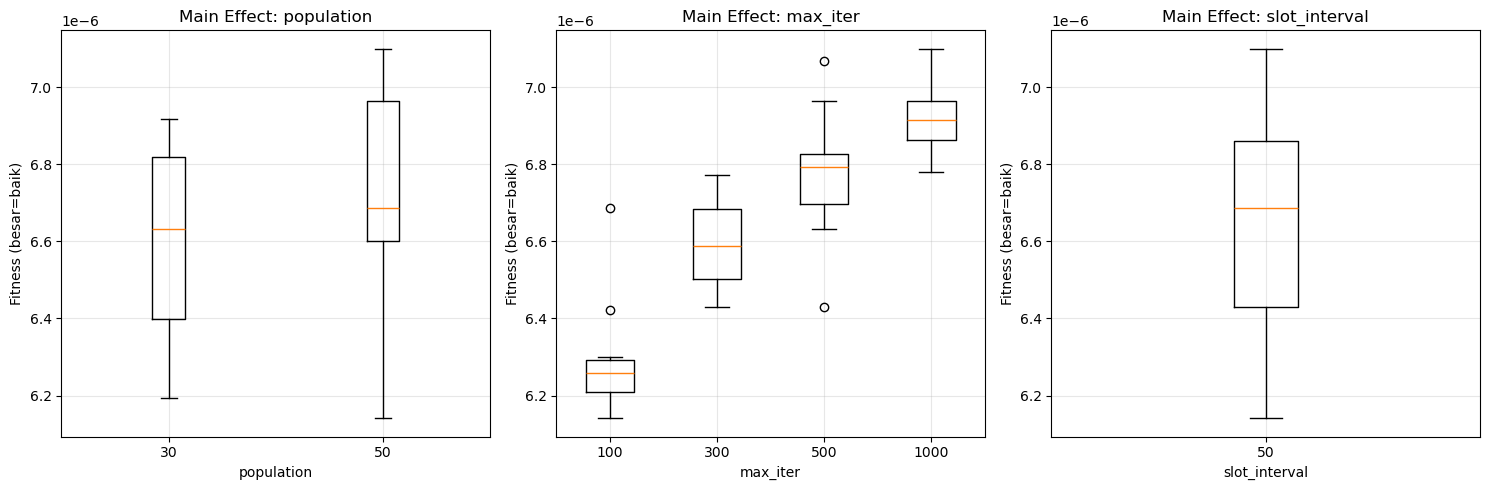

In [21]:
# Dampak relatif tiap faktor
def dampak_relatif(df, faktor, metrik='final_fitness'):
    means = df.groupby(faktor)[metrik].mean()
    return (means.max() - means.min()) / means.min() * 100.0 if means.min() > 0 else 0.0

for f in ['population', 'max_iter', 'slot_interval']:
    print(f"Dampak {f:14s} terhadap fitness: {dampak_relatif(df_detail, f):.2f}%")

# Boxplot main effect
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, f in zip(axes, ['population', 'max_iter', 'slot_interval']):
    levels = sorted(df_detail[f].unique())
    data = [df_detail[df_detail[f] == lv]['final_fitness'].values for lv in levels]
    ax.boxplot(data, labels=[str(lv) for lv in levels])
    ax.set_title(f"Main Effect: {f}")
    ax.set_xlabel(f); ax.set_ylabel("Fitness (besar=baik)")
    ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(out_path("skenario1_main_effect.png"), dpi=150)
plt.show()

## 21. Skenario 1 — Kurva Konvergensi Konfigurasi Terbaik

**(BARU).** Kurva penurunan penalty vs iterasi untuk run terbaik.

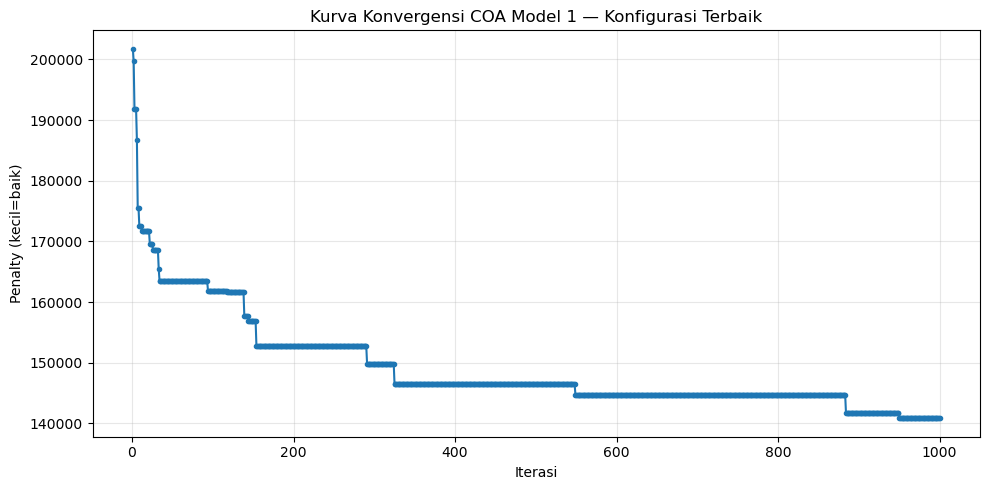

Konfigurasi terbaik: pop=50, iter=1000, int=50, seed=123


In [22]:
# Run terbaik
best_run = df_detail.loc[df_detail['final_fitness'].idxmax()]
ckpt_best = out_path(f"konvergensi_pop{int(best_run['population'])}_iter{int(best_run['max_iter'])}"
                     f"_int{int(best_run['slot_interval'])}_seed{int(best_run['seed'])}.csv")
cv = pd.read_csv(ckpt_best)
plt.figure(figsize=(10, 5))
plt.plot(cv['iterasi'], cv['penalty'], marker='.')
plt.xlabel("Iterasi"); plt.ylabel("Penalty (kecil=baik)")
plt.title("Kurva Konvergensi COA Model 1 — Konfigurasi Terbaik")
plt.grid(True, alpha=0.3); plt.tight_layout()
plt.savefig(out_path("skenario1_konvergensi.png"), dpi=150)
plt.show()
print("Konfigurasi terbaik:",
      f"pop={int(best_run['population'])}, iter={int(best_run['max_iter'])}, "
      f"int={int(best_run['slot_interval'])}, seed={int(best_run['seed'])}")

## 22. Skenario 2 — Elimination Rate & Residual per Constraint

**(BARU).** Dua grafik: elimination rate & mean residual tiap constraint. Menjawab RM-2. Dihitung agregat seluruh run.

,constraint,elimination_rate_%,mean_residual
0,H1_room_conflict,100.0,0.00
1,H2_lecturer_conflict,97.5,0.02
2,H3_lecturer_overload,5.0,4.58
3,H4_room_type_mismatch,100.0,0.00
4,H5_lunch_break,0.0,129.78
5,H6_class_completeness,100.0,0.00
6,H7_lecturer_not_interested,0.0,11.65
7,S1_floor_movement,0.0,465.90


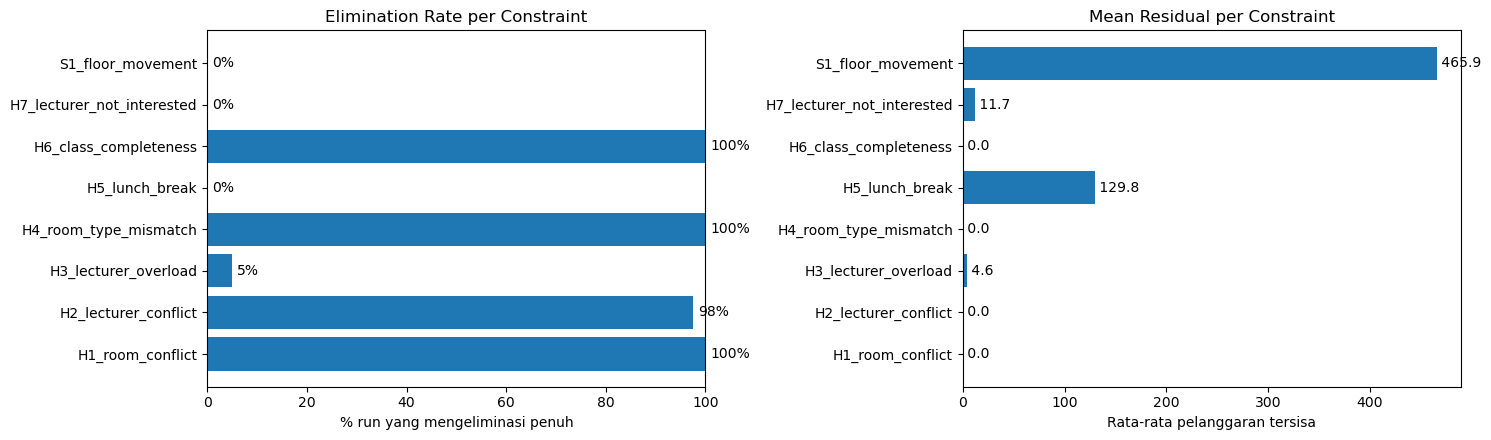

In [23]:
# Agregat elimination rate & residual lintas SEMUA run
s2 = []
for c in CONSTRAINTS:
    s2.append({'constraint': c,
               'elimination_rate_%': round((df_detail[c] == 0).mean() * 100.0, 1),
               'mean_residual': round(df_detail[c].mean(), 2)})
df_s2 = pd.DataFrame(s2)
display(df_s2)

fig, (axL, axR) = plt.subplots(1, 2, figsize=(15, 4.5))
axL.barh(df_s2['constraint'], df_s2['elimination_rate_%'])
axL.set_xlabel("% run yang mengeliminasi penuh"); axL.set_xlim(0, 100)
axL.set_title("Elimination Rate per Constraint")
for i, v in enumerate(df_s2['elimination_rate_%']):
    axL.text(v + 1, i, f"{v:.0f}%", va='center')
axR.barh(df_s2['constraint'], df_s2['mean_residual'])
axR.set_xlabel("Rata-rata pelanggaran tersisa")
axR.set_title("Mean Residual per Constraint")
for i, v in enumerate(df_s2['mean_residual']):
    axR.text(v, i, f" {v:.1f}", va='center')
plt.tight_layout()
fig.savefig(out_path("skenario2_constraint.png"), dpi=150)
plt.show()

## 23. Ekspor Jadwal Terbaik ke CSV

**(BARU).** Menerjemahkan solusi terbaik keseluruhan menjadi tabel dibaca manusia dengan kolom lengkap (termasuk Gedung, Lantai, Tipe_Ruang, Kewajiban, Feasible sesuai permintaan).

In [24]:
# Bangun ulang slot pada interval run terbaik agar index slot benar
rebuild_slots(best_overall['interval'])
best_sched = best_overall['schedule']
feasible = best_overall['eval']['is_feasible']

rows = []
for k in best_sched:
    for s in k['sesi']:
        hari, jam, menit = slots_tersedia[s['slot']]
        start_min = jam * 60 + menit
        end_min = start_min + SKS_DURATION
        info = info_ruang.get(s['ruang'], {})
        rows.append({
            'Hari'       : hari,
            'Jam_Mulai'  : f"{jam:02d}:{menit:02d}",
            'Jam_Selesai': f"{end_min//60:02d}:{end_min%60:02d}",
            'Prodi'      : k['prodi'],
            'Kode_MK'    : k['kode'],
            'Kelas'      : k['kelas'],
            'Nama_MK'    : k['nama'],
            'Jenis'      : s['tipe'],
            'Ruang'      : s['ruang'],
            'Gedung'     : info.get('gedung', ''),
            'Lantai'     : info.get('lantai', ''),
            'Tipe_Ruang' : info.get('tipe', ''),
            'Dosen'      : k['dosen'],
            'Dosen_Berminat': k['dosen'] in k['dosen_set'],  # H8: True bila dosen valid
            'SKS'        : k['sks'],
            'Kewajiban'  : k['kewajiban'],
            'Feasible'   : feasible,
        })
df_jadwal = pd.DataFrame(rows).sort_values(['Hari', 'Jam_Mulai', 'Ruang'])
JADWAL_CSV = out_path("jadwal_terbaik.csv")
df_jadwal.to_csv(JADWAL_CSV, index=False)
print("Jadwal terbaik tersimpan:", JADWAL_CSV)
display(df_jadwal.head(15))

Jadwal terbaik tersimpan: D:\Berkas UB\SKRIPSI\COATI\Coati_Optimization_University-Course-Schedulling\experiment\Final Eksperimen\Model2\jadwal_terbaik.csv


,Hari,Jam_Mulai,Jam_Selesai,Prodi,Kode_MK,Kelas,Nama_MK,Jenis,Ruang,Gedung,Lantai,Tipe_Ruang,Dosen,Dosen_Berminat,SKS,Kewajiban,Feasible
173,Fri,07:00,07:50,Sistem Informasi,CIS60103,A,Pemrograman Web Lanjut,lecture,F11.1,F,11,Kelas,22,True,3,0,False
274,Fri,07:00,07:50,Sistem Informasi,CIS61113,A,Sistem Enterprise,lecture,F2.6,F,2,Kelas,76,True,3,1,False
229,Fri,07:00,07:50,Sistem Informasi,CIS61108,A,Rekayasa Sistem Informasi,lecture,F2.8,F,2,Kelas,108,True,5,1,False
561,Fri,07:00,07:50,Pendidikan Teknologi Informasi,COM60051,A,Metodologi Penelitian dan Penulisan Ilmiah,lecture,F3.12,F,3,Kelas,100,True,3,1,False
669,Fri,07:00,07:50,Sistem Informasi,CSD60703,B,Tata Kelola Teknologi Informasi,lecture,F3.13,F,3,Kelas,6,True,3,1,False
611,Fri,07:00,07:50,Teknologi Informasi,COM60052,A,Etika Profesi,lecture,F3.15,F,3,Kelas,4,True,2,1,False
618,Fri,07:00,07:50,Teknologi Informasi,COM60052,D,Etika Profesi,lecture,F3.17,F,3,Kelas,96,True,2,1,False
142,Fri,07:00,07:50,Pendidikan Teknologi Informasi,CIE61301,A,Kalkulus dan Aljabar Linear,lecture,F4.11,F,4,Kelas,75,True,3,1,False
530,Fri,07:00,07:50,Pendidikan Teknologi Informasi,COM60016,B,Pengantar Keilmuan Komputer,lecture,F4.14,F,4,Kelas,103,True,2,1,False
798,Fri,07:00,07:50,Pendidikan Teknologi Informasi,CSD60712,C,Probabilitas dan Statistika,lecture,F4.9,F,4,Kelas,11,True,3,1,False


## 24. Laporan Ringkas (TXT)

**(BARU).** Ringkasan naratif kedua skenario untuk dilampirkan ke skripsi.

In [25]:
lines = []
lines.append("=== RINGKASAN EKSPERIMEN COA MODEL 2 (Pure COA, Random Init) ===\n")
lines.append(f"Total run: {len(df_detail)} ({len(GRID)} kombinasi x {len(SEEDS)} seed)")
lines.append("\n--- SKENARIO 1: PARAMETER ---")
for f in ['population', 'max_iter', 'slot_interval']:
    lines.append(f"Dampak {f} terhadap fitness: {dampak_relatif(df_detail, f):.2f}%")
lines.append(f"Konfigurasi terbaik: pop={int(best_run['population'])}, "
             f"iter={int(best_run['max_iter'])}, interval={int(best_run['slot_interval'])}")
lines.append("\n--- SKENARIO 2: CONSTRAINTS ---")
lines.append(f"Penalty akhir terbaik: {df_detail['final_penalty'].min()}")
lines.append(f"Run mencapai feasible: {df_detail['is_feasible'].mean()*100:.1f}%")
for _, r in df_s2.iterrows():
    lines.append(f"  {r['constraint']:24s} | elim {r['elimination_rate_%']:5.1f}% "
                 f"| residual {r['mean_residual']:.2f}")
REPORT = out_path("ringkasan_eksperimen.txt")
with open(REPORT, 'w') as f:
    f.write("\n".join(lines))
print("\n".join(lines))
print("\nLaporan tersimpan:", REPORT)

=== RINGKASAN EKSPERIMEN COA MODEL 2 (Pure COA, Random Init) ===

Total run: 40 (8 kombinasi x 5 seed)

--- SKENARIO 1: PARAMETER ---
Dampak population terhadap fitness: 1.60%
Dampak max_iter terhadap fitness: 10.03%
Dampak slot_interval terhadap fitness: 0.00%
Konfigurasi terbaik: pop=50, iter=1000, interval=50

--- SKENARIO 2: CONSTRAINTS ---
Penalty akhir terbaik: 140860
Run mencapai feasible: 0.0%
  H1_room_conflict         | elim 100.0% | residual 0.00
  H2_lecturer_conflict     | elim  97.5% | residual 0.02
  H3_lecturer_overload     | elim   5.0% | residual 4.58
  H4_room_type_mismatch    | elim 100.0% | residual 0.00
  H5_lunch_break           | elim   0.0% | residual 129.78
  H6_class_completeness    | elim 100.0% | residual 0.00
  H7_lecturer_not_interested | elim   0.0% | residual 11.65
  S1_floor_movement        | elim   0.0% | residual 465.90

Laporan tersimpan: D:\Berkas UB\SKRIPSI\COATI\Coati_Optimization_University-Course-Schedulling\experiment\Final Eksperimen\Model2\r